# Overview

The training set should be used to build your machine learning models. For the training set, we provide the outcome (also known as the “ground truth”) for each passenger. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

The test set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

# Data Dictionary
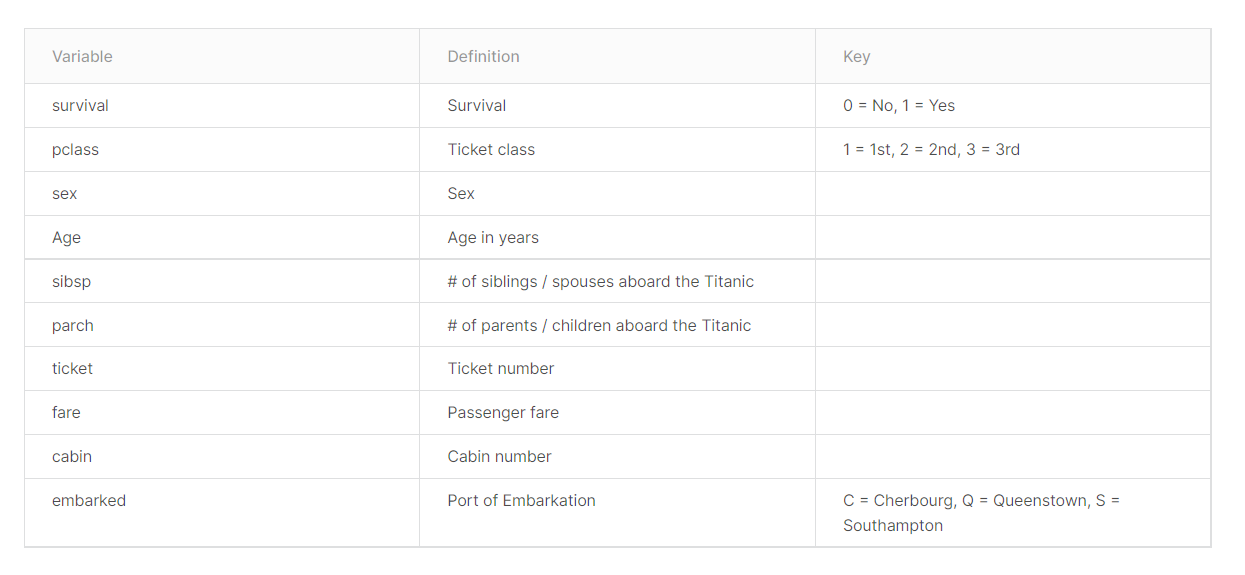


# Variable Notes
**pclass:** A proxy for socio-economic status (SES)
1st = Upper
2nd = Middle
3rd = Lower

**age:** Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

**sibsp:** The dataset defines family relations in this way...
Sibling = brother, sister, stepbrother, stepsister
Spouse = husband, wife (mistresses and fiancés were ignored)

**parch:** The dataset defines family relations in this way...
Parent = mother, father
Child = daughter, son, stepdaughter, stepson

Some children travelled only with a **nanny**, therefore **parch=0** for them

In [1]:
# Import all needed libaries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.request import urlretrieve 

print("All Modules Initialized 🚀")

# Importing the data
URL = "./titanic.csv"
titanic_df = pd.read_csv(URL)

print("Data Imported Successfully 🚀")

All Modules Initialized 🚀
Data Imported Successfully 🚀


In [2]:
# Change the Column names
titanic_df = titanic_df.rename(columns = {
    'pclass':'ticket_class',
    'ticker' : 'ticker_number',
    'cabin' : 'cabin_number',
})

In [3]:
# Change the Exbarkment values to proper words
titanic_df["Embarked"].replace({
    "C": "Cherbourg", 
    "Q": "Queenstown", 
    "S" : "Southampton"
}, inplace=True)

/tmp/ipykernel_23420/2020996471.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic_df["Embarked"].replace({


0       Queenstown
1      Southampton
2       Queenstown
3      Southampton
4      Southampton
          ...     
413    Southampton
414      Cherbourg
415    Southampton
416    Southampton
417      Cherbourg
Name: Embarked, Length: 418, dtype: str

In [4]:
# Remove PassengerId column as it's useless
titanic_df.drop("PassengerId", axis = 1, inplace = True) 

In [5]:
# See first 5 rows of data
titanic_df.head(5)

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
# See last 5 rows of data
titanic_df.tail(5)

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [8]:
# Get soome pairplots to give some UP HEAD view of the data
plt.style.use("seaborn-notebook")
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.pairplot(titanic_df)
plt.show()

OSError: 'seaborn-notebook' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

In [ ]:
# Get a heatmap of our data
titanic_mx = titanic_df.corr()

sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.heatmap(titanic_mx, annot=True, cmap='rocket')
plt.show()

In [ ]:
# Ticket Class distribution
sns.set_theme(style="whitegrid")
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.countplot(data=titanic_df, x="Pclass", palette="seismic").set(
    title = "Ticket Class Distribution"
)
plt.show()

In [ ]:
# Age distribution
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.histplot(titanic_df, x="Age", bins=25).set(
    title = "Age Distribution"
)
plt.show()

In [ ]:
# Age distribution
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.histplot(titanic_df, x="Age").set(
    title = "Age Distribution"
)
plt.show()

In [ ]:
# Fare distribution
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.histplot(titanic_df, x="Fare", bins=20).set(
    title = "Fare Distribution"
)
plt.show()

In [ ]:
# Sex Distribution 
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.countplot(data = titanic_df, x="Sex", palette="nipy_spectral").set(
    title = "Sex Distribution"
)
plt.show()

In [ ]:
# SibSp Distribution 
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.countplot(data = titanic_df, x="SibSp", palette="prism").set(
    title = "SibSp Distribution"
)
plt.show()

In [ ]:
# Parch Distribution 
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.countplot(data = titanic_df, x="Parch", palette="gnuplot").set(
    title = "Parch Distribution"
)
plt.show()

In [ ]:
# Embarkment Distribution 
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.countplot(data = titanic_df, x="Embarked", palette="gist_earth").set(
    title = "Embarkment Distribution"
)
plt.show()

In [ ]:
# Get the titles (Mr, Miss, etc.)
def get_unique_titles(list1):
    # Initialize a null list
    unique_list = []   
    # Traverse for all elements
    for x in list1:
        # check if exists in unique_list or not
        if x not in unique_list:
            unique_list.append(x)
    # Print list
    for x in unique_list:
        print(x)

titles = [i.split(",")[1].split(".")[0] for i in titanic_df["Name"]]
# get_unique_titles(titles) # Just showing off my python skills 😉

titanic_df["titles"] = titles
sns.countplot(x="titles",data=titanic_df, palette="Dark2")
plt.show()

In [ ]:
# Relationship between the fare price per gender and per embarkment
plt.style.use("fivethirtyeight")
plt.figure(figsize=(14,9))

sns.violinplot(x='Embarked',y='Fare',data=titanic_df, hue='Sex',split=True).set(
    title="Relationship between the fare price per gender and per embarkment",
    xlabel = "Embarkment", 
)
sns.stripplot(x='Embarked',y='Fare',data=titanic_df, jitter=True, 
              hue='Sex', dodge=True, palette="twilight",marker="D",size=10, edgecolor="gray", alpha=.25)

# Moves legend to the best position
plt.legend(loc=0)
plt.show()

In [ ]:
titanic_df

In [ ]:
# Relationship between SibSp & Parch per gender
plt.style.use("fivethirtyeight")
plt.figure(figsize=(14,9))

sns.violinplot(x='SibSp',y='Parch',data=titanic_df, hue='Sex',split=True).set(
    title="Relationship between the fare price per gender and per embarkment",
)
sns.stripplot(x='SibSp',y='Parch',data=titanic_df, jitter=True, 
              hue='Sex', dodge=True, palette="twilight",marker="D",size=10, edgecolor="gray", alpha=.25)

# Moves legend to the best position
plt.legend(loc=0)
plt.show()

In [ ]:
sns.kdeplot(x='SibSp', y='Parch', hue='Sex', data=titanic_df).set(
    title="Relationship between the fare price per gender and per embarkment",
)

plt.show()

In [ ]:
# Relationship between the fare price per gender and per Pclass
plt.style.use("fivethirtyeight")
plt.figure(figsize=(14,9))

sns.violinplot(x='Pclass',y='Fare',data=titanic_df, hue='Sex',split=True).set(
    title="Relationship between the fare price per gender and per Pclass",
)
sns.stripplot(x='Pclass',y='Fare',data=titanic_df, jitter=True, 
              hue='Sex', dodge=True, palette="twilight",marker="D",size=10, edgecolor="gray", alpha=.25)

# Moves legend to the best position
plt.legend(loc=0)
plt.show()

In [ ]:
sns.kdeplot(x='Pclass', y='Fare', hue='Sex', data=titanic_df).set(
    title="Relationship between the fare price per gender and per Pclass",
)

plt.show()